In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device 

device(type='cuda')

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} # string to integer mapping
stoi['.'] = 0 # add a special character for "end of word"
itos = {i:s for s,i in stoi.items()} # integer to string mapping
vocab_size = len(stoi)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
 # build the dataset
block_size = 3 # context length: how many characters do we take to predict the next

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.': # for each character plus an "end of word" character
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# Fix the initial loss
# The initial loss is too high, around 27.0
# If all the characters are uniform distribution, we expect the initial loss to be 3.29.
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [8]:
# That means we expect the initial logits to be around zero.
# That is to make W2 and b2 around zero
# That is to make b2 * 0, W2 * 0.01

In [9]:
# MLP
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g, device=device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g, device=device) * (5/3)/((n_embd*block_size)**0.5)
# b1 = torch.randn(n_hidden, generator=g, device=device) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g, device=device) * 0.01
b2 = torch.randn(vocab_size, generator=g, device=device) * 0

# batch normalization parameters
bngain = torch.ones((1, n_hidden), device=device)
bnbias = torch.zeros((1, n_hidden), device=device)
bnmean_running = torch.zeros((1, n_hidden), device=device)
bnstd_running = torch.ones((1, n_hidden), device=device)

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in the model
for p in parameters:
    p.requires_grad = True

12097


In [10]:
torch.randn(10000).std() 

tensor(0.9936)

tensor(0.0061) tensor(1.0052)
tensor(-0.0009) tensor(1.0063)


(array([2.35773044e-05, 4.71546089e-05, 4.71546089e-05, 1.65041131e-04,
        1.17886522e-04, 3.53659567e-04, 3.30082262e-04, 6.83741829e-04,
        1.69756592e-03, 2.23984392e-03, 3.84310062e-03, 5.94148072e-03,
        8.44067499e-03, 1.30382494e-02, 2.04415229e-02, 3.11456192e-02,
        4.75318457e-02, 6.70538538e-02, 9.67848347e-02, 1.35027222e-01,
        1.78857431e-01, 2.33391737e-01, 2.87030104e-01, 3.48142477e-01,
        3.93623098e-01, 4.20289029e-01, 4.25853273e-01, 4.04869472e-01,
        3.60284789e-01, 3.06198453e-01, 2.48316170e-01, 1.91400557e-01,
        1.47758967e-01, 1.05343396e-01, 7.56831472e-02, 5.07147818e-02,
        3.56253070e-02, 2.49212108e-02, 1.48301245e-02, 1.02089728e-02,
        7.14392324e-03, 4.05529636e-03, 1.98049357e-03, 1.65041131e-03,
        8.95937568e-04, 5.65855306e-04, 4.71546089e-04, 2.59350349e-04,
        9.43092177e-05, 4.71546089e-05]),
 array([-5.54539347, -5.33332512, -5.12125677, -4.90918842, -4.69712008,
        -4.48505173, 

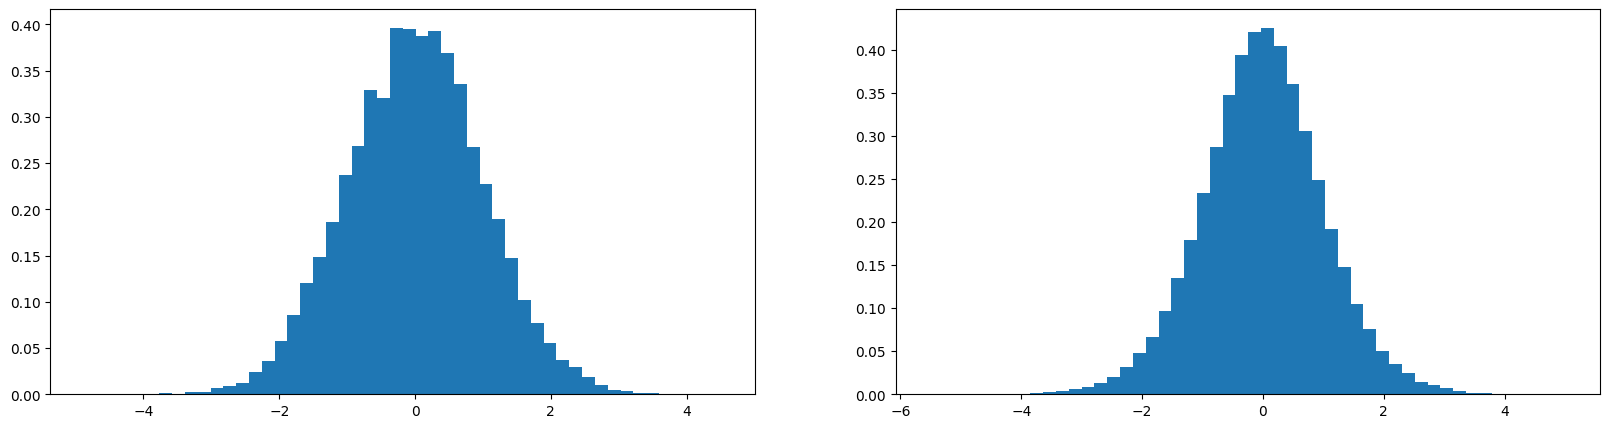

In [11]:
# we can see x is standard gaussion distribution
# y distribution is wider than x, so we need to make w thiner
# divide square root of the first dimension - the fan in
# a commonly used way to init is torch.nn.init.kaiming_normal_
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [12]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y, both of shape (batch_size, block_size) and (batch_size,) respectively

    # forward pass
    emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate the block of embeddings into a single vector, shape (batch_size, block_size * n_embd)
    # linear layer
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation, shape (batch_size, n_hidden)
    # batch normalization
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch normalize hpreact to unit Gaussion

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # non-linear activation
    h = torch.tanh(hpreact) # hidden layer, shape (batch_size, n_hidden)
    logits = h @ W2 + b2 # output layer, shape (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb) # loss function, shape (1,)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break

      0/200000: 3.2845
  10000/200000: 1.9122
  20000/200000: 2.3562
  30000/200000: 2.3121
  40000/200000: 1.9093
  50000/200000: 2.2561
  60000/200000: 1.9132
  70000/200000: 2.1371
  80000/200000: 1.9628
  90000/200000: 2.0821
 100000/200000: 2.8121
 110000/200000: 2.1500
 120000/200000: 2.1172
 130000/200000: 1.7909
 140000/200000: 2.1843
 150000/200000: 2.3734
 160000/200000: 2.1425
 170000/200000: 2.0303
 180000/200000: 2.1065
 190000/200000: 2.1415


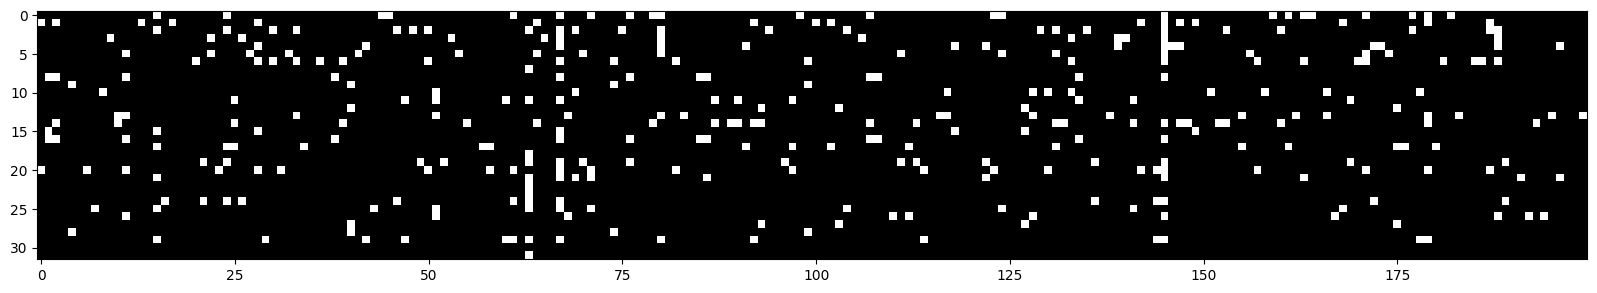

In [13]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs().detach().cpu().numpy() > 0.99, cmap='gray', interpolation='nearest')
# should not be many white blocks (>0.99), to fix this, hpreact needs to close to zero

(array([485., 224., 170., 152., 132., 116., 104., 118., 113., 117., 113.,
         88., 100.,  81., 114.,  71.,  91., 120., 102.,  82.,  81.,  93.,
         82., 105., 142.,  99., 113., 120., 115., 117., 123., 108.,  77.,
        112., 126.,  83.,  94.,  76.,  78.,  79.,  92., 114.,  83., 119.,
        136., 139., 142., 171., 250., 438.]),
 array([-9.99975026e-01, -9.59975541e-01, -9.19976056e-01, -8.79976511e-01,
        -8.39977026e-01, -7.99977541e-01, -7.59978056e-01, -7.19978571e-01,
        -6.79979086e-01, -6.39979601e-01, -5.99980056e-01, -5.59980571e-01,
        -5.19981086e-01, -4.79981601e-01, -4.39982057e-01, -3.99982572e-01,
        -3.59983087e-01, -3.19983602e-01, -2.79984117e-01, -2.39984572e-01,
        -1.99985087e-01, -1.59985602e-01, -1.19986117e-01, -7.99866319e-02,
        -3.99871469e-02,  1.23977661e-05,  4.00118232e-02,  8.00114274e-02,
         1.20010912e-01,  1.60010397e-01,  2.00009882e-01,  2.40009367e-01,
         2.80008852e-01,  3.20008337e-01,  3.60007

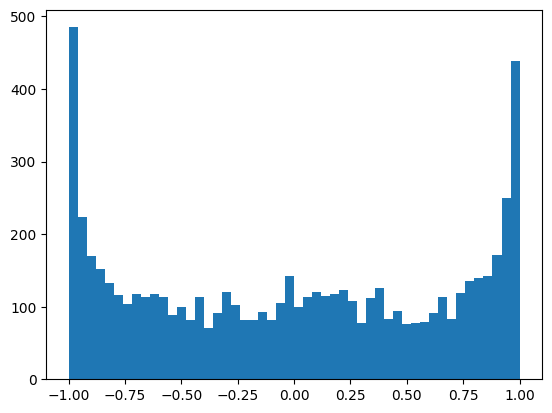

In [14]:
# h has a lot of values around 1 and -1
# further check hpreact, you will find hpreact's distribution is very wide
# in case of tanh, it will stop the back propagation
# tanh is saturated
# the neuron is dead
# we want hpreact zero mean and one standard deviation.

plt.hist(h.view(-1).detach().cpu().numpy(), 50)

(array([  1.,   0.,   0.,   4.,   6.,   7.,   7.,  21.,  26.,  58.,  59.,
         97., 132., 171., 187., 244., 303., 424., 507., 589., 758., 701.,
        419., 377., 325., 237., 221., 148., 110.,  74.,  56.,  51.,  25.,
         20.,  13.,   9.,   3.,   2.,   0.,   3.,   0.,   1.,   0.,   1.,
          1.,   0.,   0.,   0.,   1.,   1.]),
 array([-5.64482307, -5.36908627, -5.09334946, -4.81761265, -4.54187632,
        -4.26613951, -3.9904027 , -3.71466589, -3.43892932, -3.16319251,
        -2.88745594, -2.61171913, -2.33598232, -2.06024575, -1.78450894,
        -1.50877237, -1.23303556, -0.95729876, -0.68156195, -0.40582561,
        -0.13008881,  0.145648  ,  0.42138481,  0.69712162,  0.97285843,
         1.24859476,  1.52433157,  1.80006838,  2.07580519,  2.351542  ,
         2.62727833,  2.90301514,  3.17875195,  3.45448875,  3.73022556,
         4.00596237,  4.28169918,  4.55743599,  4.83317184,  5.10890865,
         5.38464546,  5.66038227,  5.93611908,  6.21185589,  6.4875927 ,
 

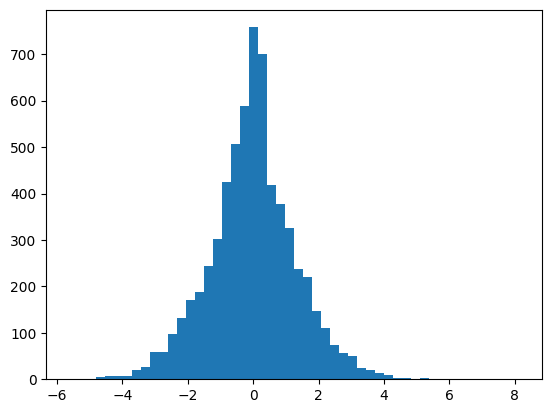

In [15]:
plt.hist(hpreact.view(-1).detach().cpu().numpy(), 50)

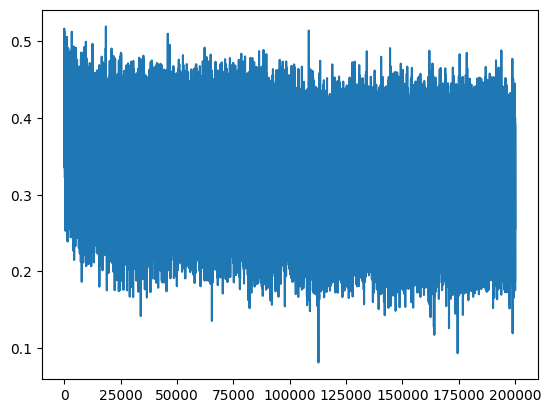

In [16]:

plt.plot(lossi)

In [17]:
# calibrate the batch normalization at the end of training
with torch.no_grad():
    # pass the training set through the network and update the batch normalization parameters
    emb = C[Xtr] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1 # (N, n_hidden)
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [18]:
bnmean, bnmean_running, bnstd, bnstd_running

(tensor([[-3.8595e-01, -2.0859e+00, -4.4502e-01, -2.7660e-01, -1.1884e+00,
          -3.7213e-01, -2.6003e+00,  2.3912e-01,  6.2918e-01,  1.8960e-01,
           2.1793e+00, -6.2534e-01, -2.2854e+00, -1.1970e+00, -1.1614e+00,
          -3.2978e-02, -6.1567e-01,  8.2017e-01, -1.3594e+00,  2.8635e-01,
           7.1154e-01, -1.5220e+00,  2.8714e-01, -1.5045e-02, -2.6372e+00,
          -1.1388e-01, -8.3741e-01,  1.2287e+00,  6.4973e-01, -2.6629e-01,
          -3.6399e-01, -7.0157e-01,  2.4860e-01, -8.7471e-01,  5.0852e-01,
           8.6113e-01,  2.4119e-02, -1.4463e-01,  9.6905e-01, -7.0341e-02,
           8.7644e-01,  1.3877e+00, -1.1067e+00, -2.1045e+00,  9.9524e-01,
          -3.4800e-01, -3.2984e-01, -1.1241e+00, -1.4293e+00,  3.2015e-01,
           1.3014e+00, -8.6828e-01, -1.9543e+00,  1.6367e+00, -3.9122e-01,
          -6.3471e-01,  3.6649e-02,  1.3244e+00, -1.6175e-01, -1.2226e+00,
          -1.6179e+00, -8.9480e-01, -1.4133e+00,  1.6002e+00,  4.8486e-01,
           3.0746e-01,  1

In [19]:
@torch.no_grad() # we don't need gradients for sampling
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (num_examples, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (num_examples, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1 # (num_examples, n_hidden)
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # batch normalize hpreact to unit Gaussion
    h = torch.tanh(hpreact) # (num_examples, n_hidden)
    logits = h @ W2 + b2 # (num_examples, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')


train loss: 2.0690
val loss: 2.1124


# loss log

# original

# fix softmax confidently wrong

# fix tanh layer too saturated at init

# use semi-principled "kaiming init" instaed of hacky init

# add a batch norm layer
batch normalization layer has its own bias bnbias, so no need for b1

In [20]:
# sampling from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initial context is all "end of word" characters
    while True:
        emb = C[torch.tensor([context], device=device)] # (1, block_size, n_embd)
        embcat = emb.view(emb.shape[0], -1) # (1, block_size * n_embd)
        hpreact = embcat @ W1 #+ b1 # (1, n_hidden)
        eps = 1e-5
        hpreact = bngain * (hpreact - bnmean_running) / (bnstd_running + eps) + bnbias # batch normalize hpreact to unit Gaussion
        h = torch.tanh(hpreact) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample from the distribution
        out.append(ix)
        context = context[1:] + [ix] # crop and append
        if ix == 0: # if we sampled the "end of word" character, stop
            break   

    print(''.join(itos[i] for i in out))

brentrysten.
maria.
kamryn.
rey.
ley.
jeiden.
murah.
emin.
jagton.
georgencis.
meth.
breyloni.
absteth.
jace.
gendyn.
zazhraan.
jullana.
dorgh.
davee.
mikh.


In [21]:
# Summary

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), device=device, generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out, device=device) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out = self.out + self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters to learn
        self.gamma = torch.ones(dim, device=device)
        self.beta = torch.zeros(dim, device=device)
        # buffers (trained with a running `momentum update`)
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var = torch.ones(dim, device=device)
        
    def __call__(self, x):
        # calcuate the foward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator(device=device).manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g, device=device)
# layers = [
#     Linear(n_embd * block_size, n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden), Tanh(),
#     Linear(n_hidden, n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size), 
# ]
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]
# Tanh is a non-linear activation function. It turns the NN from a linear model to a non-linear model, which can learn more complex functions.
# BatchNorm1d is a normalization layer. It normalizes the input to have zero mean and unit variance, which helps with training stability and convergence speed.
# Once we have the BatchNorm1d, the activation, the gradients will not explode or vanish, so we can use a larger learning rate and train deeper networks.

with torch.no_grad():
    #layers[-1].weight *= 0.1 # make the last layer thinner, so the initial loss is not too high
    layers[-1].gamma *= 0.1 # make the last layer thinner, so the initial loss is not too high
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 #(5/3)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in the model
for p in parameters:
    p.requires_grad = True

47551


In [59]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y, both of shape (batch_size, block_size) and (batch_size,) respectively

    # forward pass
    emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concatenate the block of embeddings into a single vector, shape (batch_size, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    logits = x
    loss = F.cross_entropy(logits, Yb) # loss function, shape (1,)

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # retain the gradients for all intermediate outputs
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break

      0/200000: 3.3071


# Diagnostic Tools

layer 2 (      Tanh): mean +0.00, std 0.64, saturated 2.37%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated 1.91%
layer 8 (      Tanh): mean +0.01, std 0.64, saturated 1.97%
layer 11 (      Tanh): mean -0.01, std 0.64, saturated 2.37%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated 1.69%


Text(0.5, 1.0, 'activation histograms')

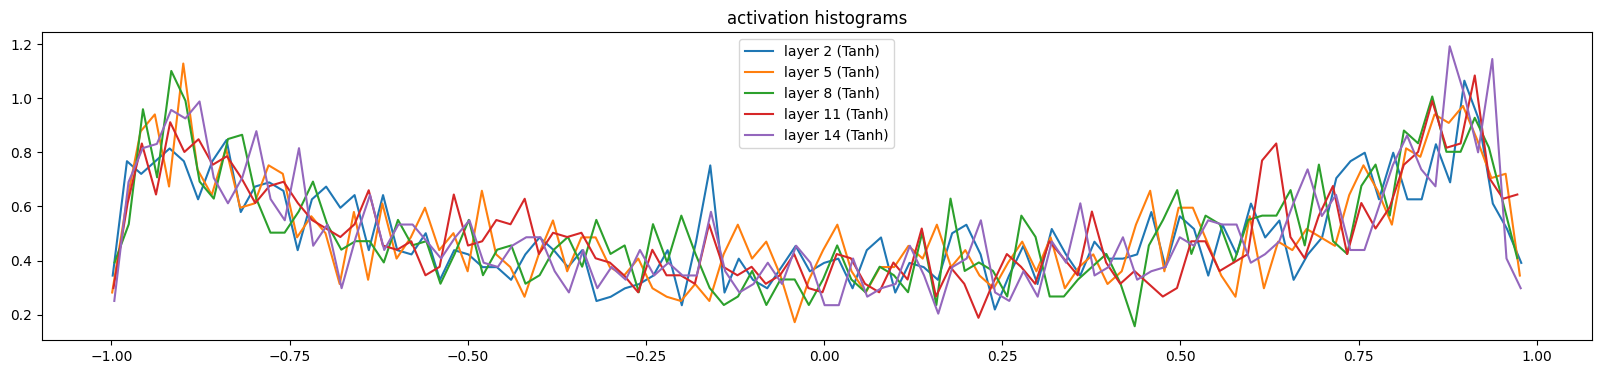

In [60]:
# visualize histograms
# change the layer.weight gain, you will see the histogram change
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item()*100))
        hy, hx = torch.histogram(t.detach().cpu(), density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation histograms')

layer 2 (      Tanh): mean -0.000000, std 3.602578e-03
layer 5 (      Tanh): mean +0.000000, std 3.217271e-03
layer 8 (      Tanh): mean +0.000000, std 2.859680e-03
layer 11 (      Tanh): mean +0.000000, std 2.670169e-03
layer 14 (      Tanh): mean +0.000000, std 2.567917e-03


Text(0.5, 1.0, 'gradient distributions')

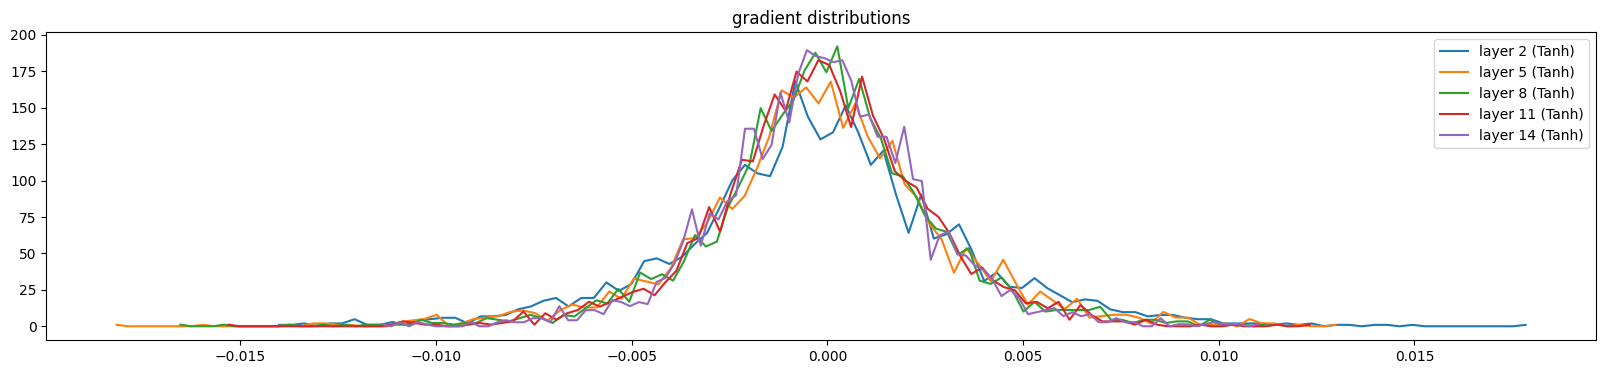

In [61]:
# visualize histograms
# change the layer.weight gain, you will see the histogram change
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t.detach().cpu(), density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distributions')

weight   (27, 10) | mean +0.000000 | std 9.736267e-03 | grad:data ratio 2.759323e-02
weight  (30, 100) | mean -0.000345 | std 8.726778e-03 | grad:data ratio 2.373250e-01
weight (100, 100) | mean +0.000076 | std 6.927694e-03 | grad:data ratio 5.260909e-01
weight (100, 100) | mean +0.000012 | std 5.946521e-03 | grad:data ratio 1.765252e-01
weight (100, 100) | mean +0.000070 | std 5.104710e-03 | grad:data ratio 1.612136e-01
weight (100, 100) | mean +0.000012 | std 4.865909e-03 | grad:data ratio 1.327657e-01
weight  (100, 27) | mean -0.000079 | std 9.080385e-03 | grad:data ratio 1.773969e-01


Text(0.5, 1.0, 'weight gradient distributions')

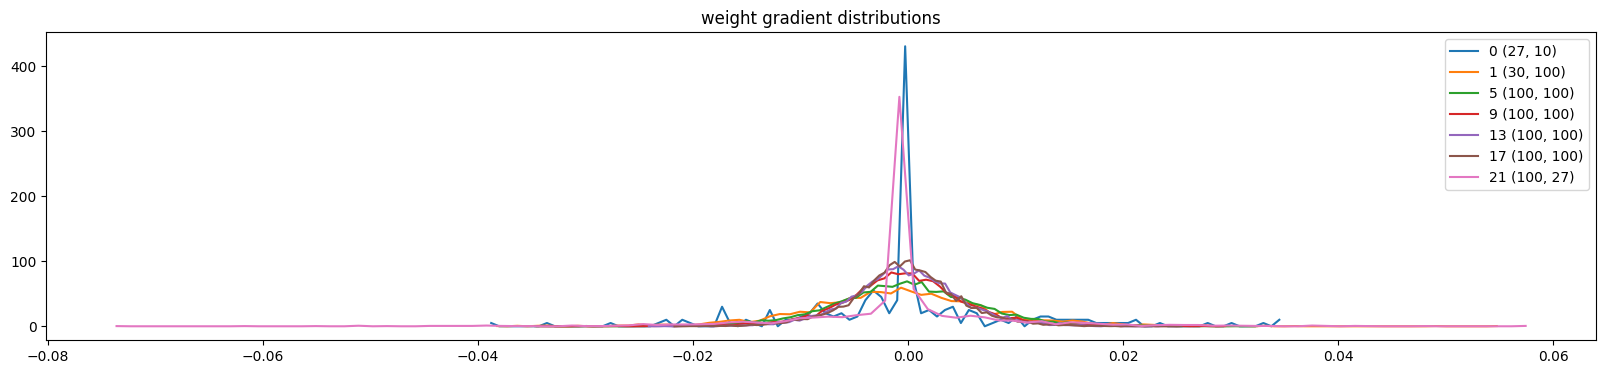

In [62]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean().item(), t.std().item(), (t.abs() / (p.abs() + 1e-8)).mean().item()))
        hy, hx = torch.histogram(t.detach().cpu(), density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weight gradient distributions')

Text(0.5, 1.0, 'weight gradient distributions')

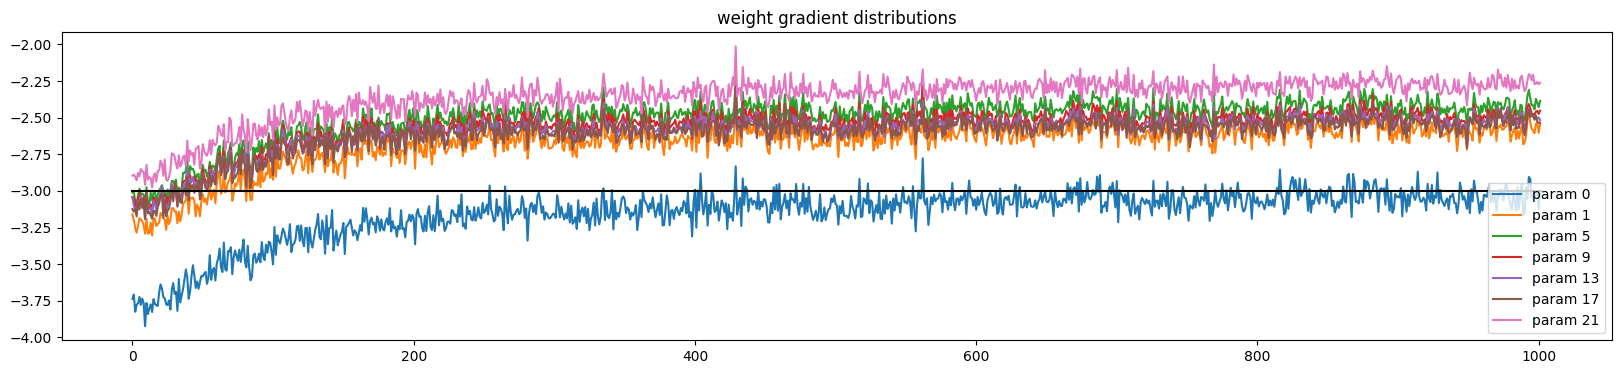

In [63]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be around 0.001 (log10 of -3), which means the gradients are around 0.1% of the weights, which is a good thing for training stability
plt.legend(legends)
plt.title('weight gradient distributions')